# Satellite–Central Cross-Correlation

Cross-`xi(r)` between satellite galaxies and central galaxies. Useful for probing the one-halo term and satellite radial profiles.

In [1]:
import matplotlib.pyplot as plt
import matplotlib as mpl
import numpy as np

import galform_analysis
from galform_analysis import set_base_dir, get_base_dir, SimulationConfig, load_redshift_mapping

mpl.setconfig()

# Configure the path to your GALFORM output directory once per session:
# set_base_dir('/cosma5/data/durham/<user>/Galform_Out/L800/model')
BASE_DIR = str(get_base_dir())
SIM = 'L800'

## Basic cross-correlation

In [2]:
from galform_analysis.analysis.correlation import satellite_central_cross_correlation
from galform_analysis.config import SimulationConfig, get_snapshot_redshift
import os

IZ_NUM = 155
iz_path = os.path.join(BASE_DIR, f'iz{IZ_NUM}')
z = get_snapshot_redshift(f'iz{IZ_NUM}', SIM)
sim = SimulationConfig(SIM)

# boxsize_override needed here because positions span the full box
res = satellite_central_cross_correlation(
    iz_path, ivol=0,
    boxsize_override=sim.box_size,
)
print(f"n_satellites={res.attrs['n_sat']:,},  n_centrals={res.attrs['n_cen']:,}")

n_satellites=136,879,  n_centrals=146,786


## With mass cuts

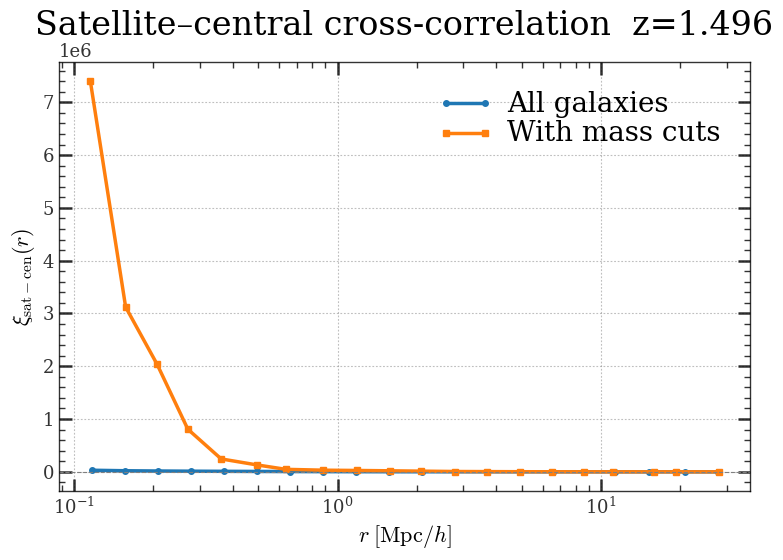

In [3]:
res_cut = satellite_central_cross_correlation(
    iz_path, ivol=0,
    satellite_stellar_mass_min=1e9,
    central_stellar_mass_min=1e10,
    host_halo_mass_min=1e12,
    boxsize_override=sim.box_size,
)

fig, ax = plt.subplots()
ax.plot(res['r'],     res['xi'],     'o-', ms=4, label='All galaxies')
if res_cut is not None:
    ax.plot(res_cut['r'], res_cut['xi'], 's-', ms=4, label='With mass cuts')
ax.axhline(0, color='0.5', lw=0.8, ls='--')
ax.set_xscale('log')
ax.set_xlabel(r'$r\;[\mathrm{Mpc}/h]$')
ax.set_ylabel(r'$\xi_{{\rm sat-cen}}(r)$')
ax.set_title(f'Satellite–central cross-correlation  z={z:.3f}')
ax.legend()
fig.tight_layout()
plt.show()